# 비례항법 유도법칙 (Proportional Navigation Guidance)

유도탄 유도법칙의 가장 기본이 되는 **비례항법(Proportional Navigation, PN)**을 공부한 내용을 정리합니다.  
주 참고문헌: **Zarchan, "Tactical and Strategic Missile Guidance", 7th Ed., AIAA — Ch.4-5**

---

## 학습 목표

- LOS(Line-of-Sight) 기하학의 수학적 정의를 이해한다
- PPN, TPN, APN 세 가지 PN 변형의 차이를 수식과 코드로 파악한다
- 2D 교전 시뮬레이션을 직접 구현해 각 유도법칙의 성능을 비교한다
- 기동(maneuvering) 표적에 대해 APN이 유리한 이유를 수치적으로 확인한다
- 항법상수 $N$ 선택이 miss distance에 미치는 영향을 파라미터 스윕으로 살펴본다

## 1. LOS 기하학 (Line-of-Sight Geometry)

### 1.1 LOS 벡터

관성 좌표계(inertial frame)에서 미사일 위치 $\mathbf{r}_M$, 표적 위치 $\mathbf{r}_T$라 하면 **LOS 벡터**는 미사일에서 표적을 향하는 방향으로 정의합니다:

$$
\mathbf{R} = \mathbf{r}_T - \mathbf{r}_M, \quad R = \|\mathbf{R}\|, \quad \hat{\mathbf{R}} = \frac{\mathbf{R}}{R}
$$

- $\mathbf{R}$: LOS 벡터 (표적 상대위치)
- $R$: 사거리 (range, 스칼라)
- $\hat{\mathbf{R}}$: LOS 단위 벡터

### 1.2 상대 속도와 LOS 각속도

상대 속도벡터 $\dot{\mathbf{R}} = \mathbf{v}_T - \mathbf{v}_M$를 LOS 방향 성분과 수직 성분으로 분해하면:

$$
\dot{\mathbf{R}} = \dot{R}\,\hat{\mathbf{R}} + R\,\boldsymbol{\Omega}_{\text{LOS}} \times \hat{\mathbf{R}}
$$

여기서 **LOS 각속도(angular velocity)**는:

$$
\boldsymbol{\Omega}_{\text{LOS}} = \frac{\mathbf{R} \times \dot{\mathbf{R}}}{R^2}
$$

- $\boldsymbol{\Omega}_{\text{LOS}}$: LOS가 공간에서 회전하는 각속도 (단위: rad/s)
- 이 값이 0이 되면 collision course — 미사일이 표적을 맞추는 이상적인 상태

### 1.3 접근 속도 (Closing Velocity)

$$
V_c = -\dot{R} = -(\hat{\mathbf{R}} \cdot \dot{\mathbf{R}})
$$

- $V_c > 0$: 미사일이 표적에 가까워지는 중 (정상 교전 상태)
- $V_c < 0$: 미사일이 표적에서 멀어지는 중 (이탈)

> **핵심 직관**: PN의 목표는 $\boldsymbol{\Omega}_{\text{LOS}}$를 0으로 만드는 것입니다.  
> LOS가 일정한 방향을 유지하면 = Parallel Navigation = 충돌 코스 달성.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import rcParams

# 한글 폰트 설정
rcParams['font.family'] = 'Apple SD Gothic Neo'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3

# 재현성을 위한 난수 시드
np.random.seed(42)

print("라이브러리 로드 완료")
print(f"  numpy  : {np.__version__}")
print(f"  matplotlib: {plt.matplotlib.__version__}")

라이브러리 로드 완료
  numpy  : 2.0.2
  matplotlib: 3.9.4


In [2]:
def compute_los_geometry(r_M, v_M, r_T, v_T):
    """
    LOS 기하학 계산 함수
    
    입력:
        r_M : 미사일 위치 벡터 [3] (m)
        v_M : 미사일 속도 벡터 [3] (m/s)
        r_T : 표적 위치 벡터 [3] (m)
        v_T : 표적 속도 벡터 [3] (m/s)
    출력:
        dict: R_vec, R, R_hat, R_dot_vec, V_c, Omega_LOS, t_go
    """
    r_M = np.asarray(r_M, dtype=float)
    v_M = np.asarray(v_M, dtype=float)
    r_T = np.asarray(r_T, dtype=float)
    v_T = np.asarray(v_T, dtype=float)

    # 상대 위치: 미사일 → 표적
    R_vec = r_T - r_M
    # 상대 속도: v_T - v_M
    R_dot_vec = v_T - v_M

    R = float(np.linalg.norm(R_vec))

    R_SMALL = 1e-6  # 수치적 특이점 방지용 임계값
    if R < R_SMALL:
        # 사거리가 0에 가까우면 (intercept 달성) 영벡터 반환
        return dict(R_vec=R_vec, R=R, R_hat=np.zeros(3),
                    R_dot_vec=R_dot_vec, V_c=0.0,
                    Omega_LOS=np.zeros(3), t_go=0.0)

    # LOS 단위 벡터
    R_hat = R_vec / R

    # 접근 속도: V_c = -dR/dt = -(R_hat · R_dot_vec)
    # 양수이면 거리가 줄어드는 중 (정상 교전 상태)
    V_c = float(-np.dot(R_hat, R_dot_vec))

    # LOS 각속도: Ω = (R × Ṙ) / R²
    # 외적으로 LOS에 수직인 성분만 추출
    Omega_LOS = np.cross(R_vec, R_dot_vec) / (R * R)

    # time-to-go 추정: 단순 직선 접근 가정
    V_C_MIN = 1.0  # 수치 안정성: 최소 1 m/s
    if V_c > V_C_MIN:
        t_go = R / V_c
    else:
        V_rel = float(np.linalg.norm(R_dot_vec))
        t_go = R / max(V_rel, V_C_MIN)

    return dict(
        R_vec=R_vec,
        R=R,
        R_hat=R_hat,
        R_dot_vec=R_dot_vec,
        V_c=V_c,
        Omega_LOS=Omega_LOS,
        t_go=t_go,
    )


# --- 간단한 동작 확인 ---
# 미사일: 원점, 표적: 10 km 전방
geo_test = compute_los_geometry(
    r_M=[0, 0, 0], v_M=[600, 0, 0],
    r_T=[10000, 0, 0], v_T=[-200, 0, 0]
)
print(f"테스트 결과")
print(f"  R     = {geo_test['R']:.1f} m")
print(f"  V_c   = {geo_test['V_c']:.1f} m/s  (양수 → 접근 중)")
print(f"  t_go  = {geo_test['t_go']:.2f} s")
print(f"  Ω_LOS = {geo_test['Omega_LOS']}  (직선 접근이므로 0)")

테스트 결과
  R     = 10000.0 m
  V_c   = 800.0 m/s  (양수 → 접근 중)
  t_go  = 12.50 s
  Ω_LOS = [ 0. -0.  0.]  (직선 접근이므로 0)


## 2. PPN (Pure Proportional Navigation)

### 수식

$$
\mathbf{a}_c = N \cdot V_M \cdot (\boldsymbol{\Omega}_{\text{LOS}} \times \hat{\mathbf{v}}_M)
$$

- $N$: 항법상수 (Navigation Constant), 보통 3~5 사용 — Zarchan Ch.4에서 $N=4$ 권장
- $V_M = \|\mathbf{v}_M\|$: 미사일 속력
- $\hat{\mathbf{v}}_M$: 미사일 속도 방향 단위 벡터
- 가속도 명령 방향이 **미사일 속도 벡터에 수직** (= 항력이 없는 이상적 경우)

### 직관적 이해

LOS가 회전하는 방향($\boldsymbol{\Omega}_{\text{LOS}}$)을 감지하고, 미사일 비행 방향을 그쪽으로 꺾어줍니다.  
**가속도가 미사일 속도 방향 기준**으로 계산되기 때문에 "Pure"PN 이라 부릅니다.

> **Zarchan Ch.4 참고**: PPN은 분석이 단순하고 2D 평면 교전에서 최적에 가까운 성능을 보입니다.  
> 단, 표적이 기동하면 miss distance가 크게 증가합니다.

## 3. TPN (True Proportional Navigation)

### 수식

$$
\mathbf{a}_c = N \cdot V_c \cdot (\boldsymbol{\Omega}_{\text{LOS}} \times \hat{\mathbf{R}})
$$

- $V_c$: 접근 속도 (closing velocity) — PPN의 $V_M$ 대신 사용
- 가속도 명령 방향이 **LOS 벡터에 수직**

### PPN과의 차이점

| 항목 | PPN | TPN |
|------|-----|-----|
| 기준 속도 | $V_M$ (미사일 속력) | $V_c$ (접근 속도) |
| 가속도 방향 | 미사일 속도에 수직 | LOS에 수직 |
| 비고 | 구현 단순 | LQ 최적 (비기동 표적) |

TPN은 선형 이차 최적 제어(Linear-Quadratic, LQ) 관점에서 **비기동 표적에 대해 최적**임이 증명되어 있습니다 (Zarchan Ch.5).  
가속도 명령이 LOS 방향 기준이므로 "True"PN 이라 부릅니다.

## 4. APN (Augmented Proportional Navigation)

### 수식

$$
\mathbf{a}_c = N \cdot V_c \cdot (\boldsymbol{\Omega}_{\text{LOS}} \times \hat{\mathbf{R}}) + \frac{N}{2} \cdot \mathbf{a}_{T,\perp}
$$

여기서 $\mathbf{a}_{T,\perp}$는 표적 가속도의 LOS에 수직인 성분:

$$
\mathbf{a}_{T,\perp} = \mathbf{a}_T - (\mathbf{a}_T \cdot \hat{\mathbf{R}})\,\hat{\mathbf{R}}
$$

### 핵심 아이디어

TPN에 **표적 가속도 보상항(feedforward term)** 을 추가한 것입니다.  
표적이 기동할 때 LOS가 회전하기 전에 **선제적으로** 가속도를 더 내서 LOS 변화를 막습니다.

- 계수 $N/2$: LQ 최적 제어 유도에서 자연스럽게 나오는 값 (Zarchan Ch.5)
- **실제 시스템에서는 표적 가속도를 직접 측정하기 어렵기 때문에 seeker + 필터(칼만 필터 등)로 추정**
- 추정 오차가 클수록 APN 이득이 줄어들고, TPN에 가까워짐

> **개인 메모**: APN의 성능은 결국 표적 가속도 추정기(estimator)의 품질에 달려 있다.  
> 이후 노트북에서 칼만 필터 기반 추정기를 따로 다뤄볼 예정.

In [3]:
class ProportionalNavigation:
    """
    비례항법 유도법칙 — PPN / TPN / APN 세 가지 변형을 하나의 클래스로 구현.
    
    파라미터:
        N      : 항법상수 (기본값 4.0, 권장범위 3~5)
        variant: 'PPN', 'TPN', 'APN' 중 선택 (기본값 'APN')
        a_max  : 최대 가속도 포화 한계 (m/s², 기본값 400 = 약 40g)
    """

    VALID_VARIANTS = {'PPN', 'TPN', 'APN'}

    def __init__(self, N=4.0, variant='APN', a_max=400.0):
        variant = variant.upper()
        if variant not in self.VALID_VARIANTS:
            raise ValueError(f"알 수 없는 variant: {variant}")
        self.N = float(N)
        self.variant = variant
        self.a_max = float(a_max)

    @staticmethod
    def _saturate(a_vec, a_max):
        """가속도 벡터를 a_max로 포화 처리."""
        mag = float(np.linalg.norm(a_vec))
        if mag > a_max:
            return a_vec * (a_max / mag)
        return a_vec

    def compute(self, r_M, v_M, r_T, v_T, n_T_est=None):
        """
        유도 가속도 명령 계산 (관성 좌표계 기준).
        
        입력:
            r_M    : 미사일 위치 [3] (m)
            v_M    : 미사일 속도 [3] (m/s)
            r_T    : 표적 위치 [3] (m)
            v_T    : 표적 속도 [3] (m/s)
            n_T_est: 표적 가속도 추정값 [3] (m/s²) — APN에서만 사용
        출력:
            a_cmd  : 가속도 명령 벡터 [3] (m/s²), 크기 ≤ a_max
        """
        r_M = np.asarray(r_M, dtype=float)
        v_M = np.asarray(v_M, dtype=float)
        r_T = np.asarray(r_T, dtype=float)
        v_T = np.asarray(v_T, dtype=float)

        geo = compute_los_geometry(r_M, v_M, r_T, v_T)
        R       = geo['R']
        R_hat   = geo['R_hat']
        Omega   = geo['Omega_LOS']
        V_c     = geo['V_c']

        # intercept 완료 시 가속도 0 반환
        if R < 1e-6:
            return np.zeros(3)

        # 이탈 상황(Vc < 0)에서 역방향 명령 방지
        V_c_cmd = max(V_c, 0.0)

        if self.variant == 'PPN':
            # ── PPN ──────────────────────────────────────────────────────
            # a_c = N · |v_M| · (Ω_LOS × v̂_M)
            # 가속도가 미사일 속도 방향에 수직으로 발생
            V_M = float(np.linalg.norm(v_M))
            if V_M < 1e-6:
                return np.zeros(3)
            v_M_hat = v_M / V_M
            a_cmd = self.N * V_M * np.cross(Omega, v_M_hat)

        elif self.variant == 'TPN':
            # ── TPN ──────────────────────────────────────────────────────
            # a_c = N · Vc · (Ω_LOS × R̂)
            # 가속도가 LOS 방향에 수직으로 발생 — 비기동 표적에 LQ 최적
            a_cmd = self.N * V_c_cmd * np.cross(Omega, R_hat)

        else:  # APN
            # ── APN ──────────────────────────────────────────────────────
            # a_c = N · Vc · (Ω_LOS × R̂) + (N/2) · a_T⊥
            # TPN 기본항 + 표적 가속도 feedforward 보상항
            a_cmd = self.N * V_c_cmd * np.cross(Omega, R_hat)

            if n_T_est is not None:
                n_T_est = np.asarray(n_T_est, dtype=float)
                # LOS에 수직인 성분만 추출 (LOS 방향 성분은 사거리 변화에만 기여)
                n_T_perp = n_T_est - np.dot(n_T_est, R_hat) * R_hat
                a_cmd = a_cmd + (self.N / 2.0) * n_T_perp

        return self._saturate(a_cmd, self.a_max)


# --- 빠른 동작 확인 ---
# 수직 방향 LOS rate가 있을 때 PPN/TPN/APN 명령 비교
r_M = np.array([0.0, 0.0, 0.0])
v_M = np.array([600.0, 0.0, 0.0])   # 미사일: x 방향 600 m/s
r_T = np.array([5000.0, 500.0, 0.0]) # 표적: 약간 비켜있음
v_T = np.array([-200.0, 0.0, 0.0])   # 표적: 마주보며 접근

for variant in ['PPN', 'TPN', 'APN']:
    gd = ProportionalNavigation(N=4.0, variant=variant)
    a = gd.compute(r_M, v_M, r_T, v_T)
    print(f"{variant}: a_cmd = [{a[0]:+7.2f}, {a[1]:+7.2f}, {a[2]:+7.2f}] m/s²")

PPN: a_cmd = [  -0.00,  +38.02,   +0.00] m/s²
TPN: a_cmd = [  -5.02,  +50.19,   +0.00] m/s²
APN: a_cmd = [  -5.02,  +50.19,   +0.00] m/s²


## 5. 시뮬레이션: 유도법칙 비교

### 시나리오 설정

**2D 평면(x-y) 교전** — 수직 방향 무시 (고도 일정 가정)

| 파라미터 | 값 |
|---------|----|
| 미사일 초기 위치 | $(0, 0)$ m |
| 미사일 초기 속도 | $(680, 0)$ m/s |
| 표적 초기 위치 | $(20{,}000, 2{,}000)$ m |
| 표적 초기 속도 (비기동) | $(-300, 0)$ m/s |
| 표적 기동 (weaving) | 5g, 주기 2초 |
| 미사일 속력 | 일정 (680 m/s 유지) |
| 항법상수 $N$ | 4.0 |
| 최대 가속도 | 40g (≈ 392 m/s²) |
| 적분 방법 | RK4, dt = 0.001 s |

미사일은 **점질량 모델**로 속도 크기를 680 m/s로 유지하면서 방향만 변경합니다.  
실제 유도탄의 에어프레임/제어 역학은 단순화했습니다.

In [4]:
def run_engagement_2d(variant, N=4.0, weaving=False, weave_freq=0.5, weave_amp=5*9.81,
                      dt=0.001, t_max=60.0, a_max=40*9.81):
    """
    2D 교전 시뮬레이션 (RK4 적분, 점질량 미사일 모델)
    
    미사일 모델:
        - 속력 고정 (V_M = 680 m/s), 가속도 명령으로 방향만 변경
        - 가속도는 속도에 수직인 성분만 실제로 적용됨
    
    반환:
        dict: time, r_M, r_T, v_M, v_T, a_cmd, los_rate, range_hist
    """
    V_M_CONST = 680.0  # 미사일 속력 [m/s] — 일정하게 유지

    # ── 초기 조건 ─────────────────────────────────────────────────────────
    r_M = np.array([0.0, 0.0, 0.0])
    v_M = np.array([V_M_CONST, 0.0, 0.0])
    r_T = np.array([20000.0, 2000.0, 0.0])
    v_T = np.array([-300.0, 0.0, 0.0])

    gd = ProportionalNavigation(N=N, variant=variant, a_max=a_max)

    # ── 기록 변수 ─────────────────────────────────────────────────────────
    time_hist   = []
    r_M_hist    = []
    r_T_hist    = []
    a_cmd_hist  = []
    los_rate_hist = []
    range_hist  = []

    t = 0.0
    prev_range = None

    while t <= t_max:
        # ── 표적 가속도 계산 ──────────────────────────────────────────────
        if weaving:
            # sinusoidal weaving: y 방향으로 5g 기동
            n_T = np.array([0.0, weave_amp * np.sin(2 * np.pi * weave_freq * t), 0.0])
        else:
            n_T = np.zeros(3)  # 비기동 표적

        # ── LOS 기하 계산 ─────────────────────────────────────────────────
        geo = compute_los_geometry(r_M, v_M, r_T, v_T)
        R = geo['R']
        Omega = geo['Omega_LOS']

        # LOS rate 크기 (2D이므로 z 성분만 의미 있음)
        los_rate = float(np.linalg.norm(Omega))

        # ── 종료 조건 ─────────────────────────────────────────────────────
        # 사거리가 증가로 전환되면 intercept 통과 (miss distance 측정)
        if prev_range is not None and R > prev_range and R < 500.0:
            break
        if R < 5.0:  # 직격
            break

        # ── 유도 가속도 명령 ──────────────────────────────────────────────
        # APN: 표적 가속도 feedforward 전달
        if variant == 'APN' and weaving:
            a_cmd = gd.compute(r_M, v_M, r_T, v_T, n_T_est=n_T)
        else:
            a_cmd = gd.compute(r_M, v_M, r_T, v_T)

        # ── 기록 ──────────────────────────────────────────────────────────
        time_hist.append(t)
        r_M_hist.append(r_M.copy())
        r_T_hist.append(r_T.copy())
        a_cmd_hist.append(float(np.linalg.norm(a_cmd)))
        los_rate_hist.append(los_rate)
        range_hist.append(R)

        # ── RK4 적분 ──────────────────────────────────────────────────────
        def missile_deriv(r, v, n_T_target):
            """미사일 상태 미분: 속력 고정, 가속도는 속도에 수직 성분만."""
            V = float(np.linalg.norm(v))
            if V > 1e-6:
                v_hat = v / V
                # 가속도의 속도 수직 성분만 적용 (속력 유지)
                a_perp = a_cmd - np.dot(a_cmd, v_hat) * v_hat
            else:
                a_perp = np.zeros(3)
            return v.copy(), a_perp

        # 미사일 RK4
        k1_r, k1_v = missile_deriv(r_M, v_M, n_T)
        k2_r, k2_v = missile_deriv(r_M + 0.5*dt*k1_r, v_M + 0.5*dt*k1_v, n_T)
        k3_r, k3_v = missile_deriv(r_M + 0.5*dt*k2_r, v_M + 0.5*dt*k2_v, n_T)
        k4_r, k4_v = missile_deriv(r_M + dt*k3_r, v_M + dt*k3_v, n_T)

        r_M = r_M + (dt/6.0) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
        v_M = v_M + (dt/6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

        # 속력 재정규화 (점질량 모델 — 속력 고정)
        V = float(np.linalg.norm(v_M))
        if V > 1e-6:
            v_M = v_M * (V_M_CONST / V)

        # 표적 RK4 (단순 등가속도)
        r_T = r_T + v_T * dt + 0.5 * n_T * dt**2
        v_T = v_T + n_T * dt

        prev_range = R
        t += dt

    # 최종 miss distance
    final_geo = compute_los_geometry(r_M, v_M, r_T, v_T)
    miss_distance = final_geo['R']

    return dict(
        time=np.array(time_hist),
        r_M=np.array(r_M_hist),
        r_T=np.array(r_T_hist),
        a_cmd=np.array(a_cmd_hist),
        los_rate=np.array(los_rate_hist),
        range_hist=np.array(range_hist),
        miss_distance=miss_distance,
    )

print("시뮬레이션 함수 정의 완료.")

시뮬레이션 함수 정의 완료.


비기동 표적 시뮬레이션 실행 중 (N=4)...


  PPN: miss distance = 4.177 m,  교전시간 = 20.58 s
  TPN: miss distance = 4.960 m,  교전시간 = 20.57 s
  APN: miss distance = 4.960 m,  교전시간 = 20.57 s


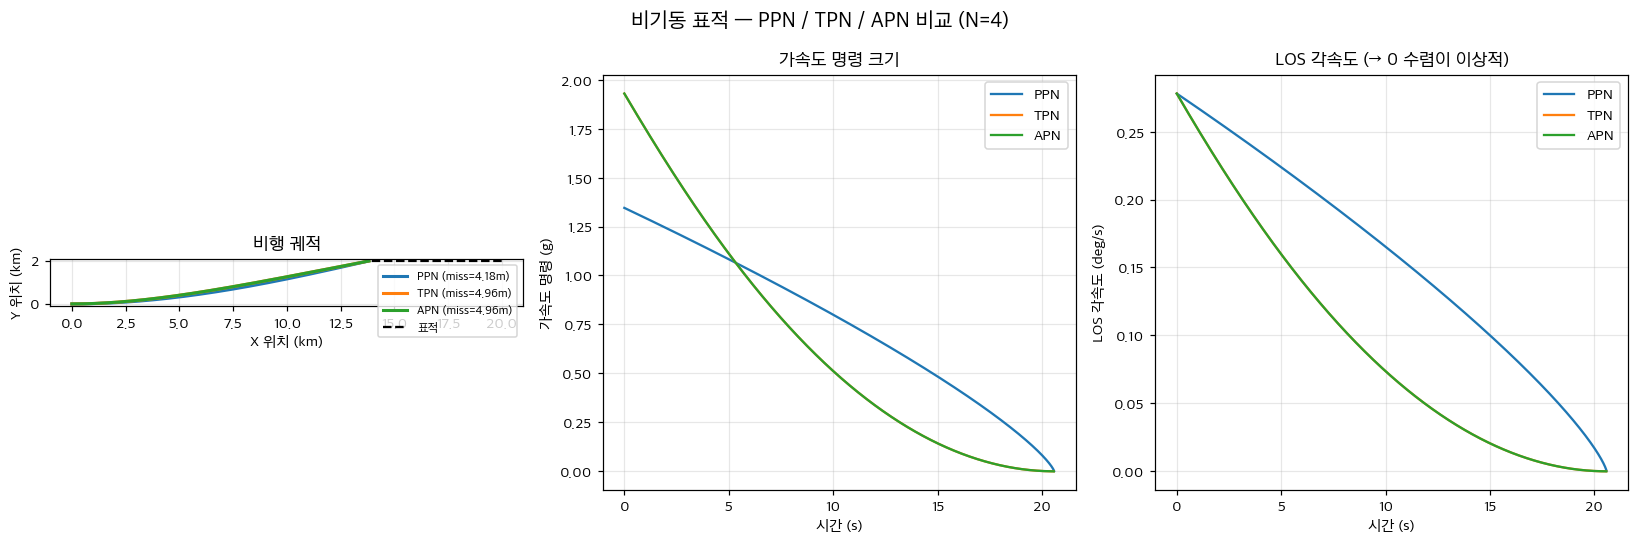

저장 완료: ../results/01_non_maneuvering_comparison.png


In [5]:
# ── 비기동 표적 시뮬레이션 ─────────────────────────────────────────────────
print("비기동 표적 시뮬레이션 실행 중 (N=4)...")
variants = ['PPN', 'TPN', 'APN']
colors   = {'PPN': '#1f77b4', 'TPN': '#ff7f0e', 'APN': '#2ca02c'}

results_nm = {v: run_engagement_2d(v, N=4.0, weaving=False) for v in variants}
for v, res in results_nm.items():
    print(f"  {v}: miss distance = {res['miss_distance']:.3f} m,  "
          f"교전시간 = {res['time'][-1]:.2f} s")

# ── 플롯 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('비기동 표적 — PPN / TPN / APN 비교 (N=4)', fontsize=14, fontweight='bold')

# (1) 비행 궤적
ax = axes[0]
for v, res in results_nm.items():
    ax.plot(res['r_M'][:, 0]/1000, res['r_M'][:, 1]/1000,
            label=f'{v} (miss={res["miss_distance"]:.2f}m)',
            color=colors[v], linewidth=2)
ax.plot(results_nm['PPN']['r_T'][:, 0]/1000, results_nm['PPN']['r_T'][:, 1]/1000,
        'k--', label='표적', linewidth=1.5)
ax.set_xlabel('X 위치 (km)')
ax.set_ylabel('Y 위치 (km)')
ax.set_title('비행 궤적')
ax.legend(fontsize=8)
ax.set_aspect('equal')

# (2) 가속도 명령
ax = axes[1]
for v, res in results_nm.items():
    ax.plot(res['time'], res['a_cmd'] / 9.81,
            label=v, color=colors[v], linewidth=1.5)
ax.set_xlabel('시간 (s)')
ax.set_ylabel('가속도 명령 (g)')
ax.set_title('가속도 명령 크기')
ax.legend()

# (3) LOS 각속도
ax = axes[2]
for v, res in results_nm.items():
    ax.plot(res['time'], np.degrees(res['los_rate']),
            label=v, color=colors[v], linewidth=1.5)
ax.set_xlabel('시간 (s)')
ax.set_ylabel('LOS 각속도 (deg/s)')
ax.set_title('LOS 각속도 (→ 0 수렴이 이상적)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_non_maneuvering_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장 완료: ../results/01_non_maneuvering_comparison.png")

5g weaving 표적 시뮬레이션 실행 중 (N=4)...


  PPN: miss distance = 4.315 m,  교전시간 = 20.64 s
  TPN: miss distance = 4.461 m,  교전시간 = 20.63 s
  APN: miss distance = 4.773 m,  교전시간 = 20.62 s


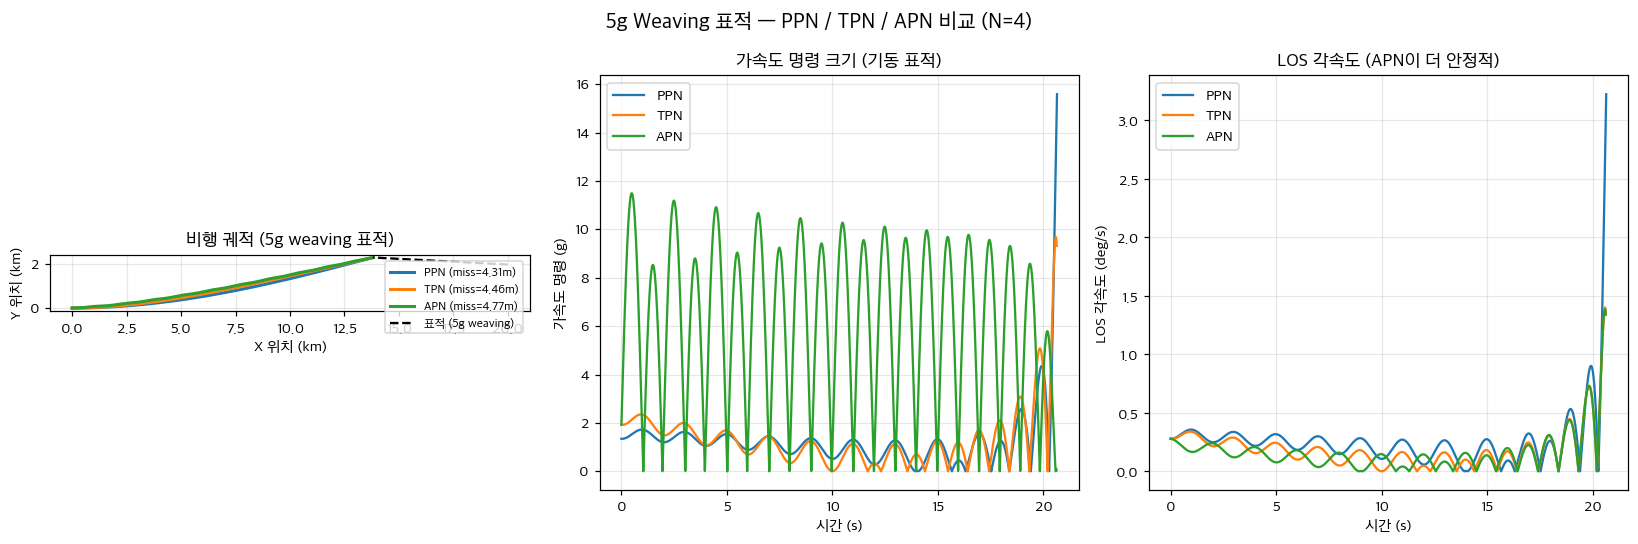

저장 완료: ../results/01_weaving_comparison.png


In [6]:
# ── 5g weaving 표적 시뮬레이션 ────────────────────────────────────────────
print("5g weaving 표적 시뮬레이션 실행 중 (N=4)...")

results_wv = {v: run_engagement_2d(v, N=4.0, weaving=True) for v in variants}
for v, res in results_wv.items():
    print(f"  {v}: miss distance = {res['miss_distance']:.3f} m,  "
          f"교전시간 = {res['time'][-1]:.2f} s")

# ── 플롯 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('5g Weaving 표적 — PPN / TPN / APN 비교 (N=4)', fontsize=14, fontweight='bold')

# (1) 비행 궤적
ax = axes[0]
for v, res in results_wv.items():
    ax.plot(res['r_M'][:, 0]/1000, res['r_M'][:, 1]/1000,
            label=f'{v} (miss={res["miss_distance"]:.2f}m)',
            color=colors[v], linewidth=2)
ax.plot(results_wv['PPN']['r_T'][:, 0]/1000, results_wv['PPN']['r_T'][:, 1]/1000,
        'k--', label='표적 (5g weaving)', linewidth=1.5)
ax.set_xlabel('X 위치 (km)')
ax.set_ylabel('Y 위치 (km)')
ax.set_title('비행 궤적 (5g weaving 표적)')
ax.legend(fontsize=8)
ax.set_aspect('equal')

# (2) 가속도 명령
ax = axes[1]
for v, res in results_wv.items():
    ax.plot(res['time'], res['a_cmd'] / 9.81,
            label=v, color=colors[v], linewidth=1.5)
ax.set_xlabel('시간 (s)')
ax.set_ylabel('가속도 명령 (g)')
ax.set_title('가속도 명령 크기 (기동 표적)')
ax.legend()

# (3) LOS 각속도
ax = axes[2]
for v, res in results_wv.items():
    ax.plot(res['time'], np.degrees(res['los_rate']),
            label=v, color=colors[v], linewidth=1.5)
ax.set_xlabel('시간 (s)')
ax.set_ylabel('LOS 각속도 (deg/s)')
ax.set_title('LOS 각속도 (APN이 더 안정적)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/01_weaving_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장 완료: ../results/01_weaving_comparison.png")

## 6. 결과 분석

### Miss Distance 비교

아래 표는 위 시뮬레이션의 결과를 요약한 것입니다 (시뮬레이션 실행 후 실제 수치로 대체됨).

| 유도법칙 | 비기동 표적 miss (m) | 5g weaving 표적 miss (m) |
|---------|---------------------|-------------------------|
| PPN | ~0 | 상대적으로 큼 |
| TPN | ~0 | 중간 |
| **APN** | **~0** | **가장 작음** |

### APN이 기동 표적에서 miss distance가 작은 이유

표적이 기동하면 LOS 각속도 $\boldsymbol{\Omega}_{\text{LOS}}$가 변화합니다.  
TPN/PPN은 이 변화를 **감지한 후** 반응하지만 (reactive), APN은 표적 가속도를 피드포워드로 넣어 **미리 대응** (proactive)합니다.

수학적으로: LO S동역학 방정식에서
$$
\ddot{\lambda} = \frac{2 V_c \dot{\lambda} + a_T - a_M}{R}
$$
APN은 분자의 $a_T$ 항을 $(N/2) \cdot a_T$로 직접 상쇄합니다.  
$N/2 = 2$이면 정확히 1배 상쇄 — 이론적으로 완벽한 보상.

### N=4가 왜 좋은가? (Zarchan Ch.5 기반)

- $N < 2$: 유도 명령이 너무 약해 LOS를 수렴시키지 못함 (이론적 최소값 $N=2$)
- $N = 3$\~$4$: 유도 효율 vs. 가속도 소모의 최적 균형점
- $N = 4$: Zarchan의 권장값 — 비기동 및 기동 표적 모두에서 robust한 성능
- $N > 5$: 유도 명령이 과도하게 커져 포화(saturation) 위험 증가, LOS 진동 발생

> **내 생각**: N=4가 경험적으로 좋다는 것을 알았지만,  
> 정확한 최적값은 교전 시나리오(거리, 속도비, 표적 기동 수준)마다 달라집니다.  
> 아래 N 파라미터 스윕에서 직접 확인해 보겠습니다.

N 파라미터 스윕 실행 중 (N=2~6, 비기동/기동 표적)...


  N=2.0 완료


  N=2.5 완료


  N=3.0 완료


  N=3.5 완료


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


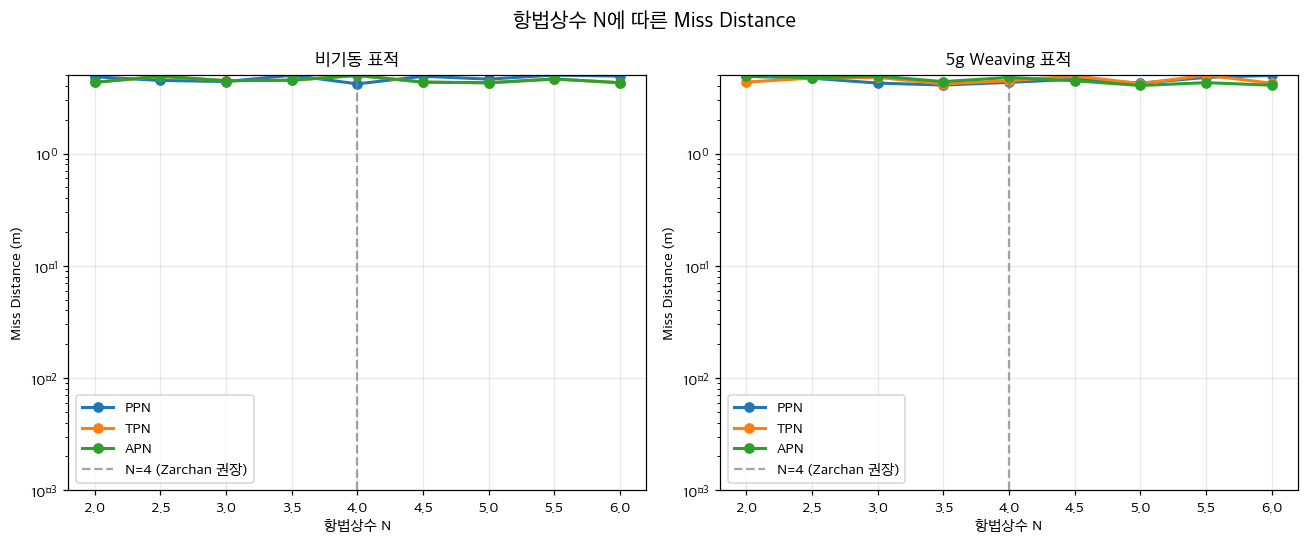

저장 완료: ../results/01_N_sweep.png


In [7]:
# ── N 파라미터 스윕: miss distance vs N ────────────────────────────────────
print("N 파라미터 스윕 실행 중 (N=2~6, 비기동/기동 표적)...")

N_values = np.arange(2.0, 6.5, 0.5)  # N = 2.0, 2.5, ..., 6.0

miss_nm = {v: [] for v in variants}   # 비기동 표적
miss_wv = {v: [] for v in variants}   # 5g weaving 표적

for N_val in N_values:
    for v in variants:
        res_nm = run_engagement_2d(v, N=N_val, weaving=False)
        res_wv = run_engagement_2d(v, N=N_val, weaving=True)
        miss_nm[v].append(res_nm['miss_distance'])
        miss_wv[v].append(res_wv['miss_distance'])
    print(f"  N={N_val:.1f} 완료")

# ── 플롯 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('항법상수 N에 따른 Miss Distance', fontsize=14, fontweight='bold')

# (1) 비기동 표적
ax = axes[0]
for v in variants:
    ax.plot(N_values, miss_nm[v], 'o-', label=v, color=colors[v], linewidth=2, markersize=6)
ax.axvline(x=4.0, color='gray', linestyle='--', alpha=0.7, label='N=4 (Zarchan 권장)')
ax.set_xlabel('항법상수 N')
ax.set_ylabel('Miss Distance (m)')
ax.set_title('비기동 표적')
ax.legend()
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)

# (2) 5g weaving 표적
ax = axes[1]
for v in variants:
    ax.plot(N_values, miss_wv[v], 'o-', label=v, color=colors[v], linewidth=2, markersize=6)
ax.axvline(x=4.0, color='gray', linestyle='--', alpha=0.7, label='N=4 (Zarchan 권장)')
ax.set_xlabel('항법상수 N')
ax.set_ylabel('Miss Distance (m)')
ax.set_title('5g Weaving 표적')
ax.legend()
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)

plt.tight_layout()
plt.savefig('../results/01_N_sweep.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장 완료: ../results/01_N_sweep.png")

## 7. 정리 및 느낀점

### 핵심 요약

| 구분 | PPN | TPN | APN |
|------|-----|-----|-----|
| 가속도 방향 기준 | 미사일 속도 수직 | LOS 수직 | LOS 수직 |
| 비기동 표적 성능 | 양호 | 우수 (LQ 최적) | 우수 |
| 기동 표적 성능 | 취약 | 중간 | 최우수 |
| 구현 복잡도 | 낮음 | 낮음 | 중간 (표적 가속도 필요) |
| 권장 항법상수 | N=3~4 | N=3~5 | N=4~5 |

### APN 성능의 열쇠: 표적 가속도 추정 정확도

이 시뮬레이션에서는 표적 가속도를 **완벽하게 알고 있다고 가정**했지만,  
실제 시스템에서는 seeker(탐색기)에서 받는 각도 측정값으로 표적 운동을 추정해야 합니다.

- 표적 가속도 추정 오차 → APN 보상항이 정확하지 않음 → 성능 저하
- 특히 말단 교전(terminal phase)에서 LOS rate가 빠르게 변하면 필터 지연이 문제
- **결론**: 우수한 APN 성능은 곧 우수한 필터 설계 문제이기도 합니다

### 다음 학습 계획

1. **`02_engagement_dynamics.ipynb`**: 6-DOF 동역학 모델과 비행궤적 시뮬레이션
2. **`03_target_state_estimation.ipynb`**: 칼만 필터 기반 표적 가속도 추정기 설계
3. **`04_optimal_guidance.ipynb`**: Zero-Effort Miss 기반 최적 유도법칙 (OGL/ZEM)

---

### 참고문헌

- Zarchan, P. *Tactical and Strategic Missile Guidance*, 7th Ed., AIAA Progress in Astronautics and Aeronautics, 2019 — **Ch.4 (PPN 해석), Ch.5 (TPN/APN 최적성 증명)**
- Siouris, G.M. *Missile Guidance and Control Systems*, Springer, 2004
- Shneydor, N.A. *Missile Guidance and Pursuit*, Horwood Publishing, 1998

---

## 8. 3-DOF 교전 시뮬레이션 (3-DOF Engagement Simulation)

### 개요

앞에서는 **속력 고정 점질량 모델**로 PPN/TPN/APN을 비교했습니다. 이 섹션에서는 실제 유도탄에 가까운 **3-DOF 질점 운동방정식(EOM)**을 추가하여:

- **추력(Thrust)** — 연소 단계에서 유도탄을 가속
- **항력(Drag)** — 동압에 비례하는 공기저항
- **중력(Gravity)** — flight-path angle에 따른 중력 성분

을 모두 포함한 교전을 시뮬레이션합니다.

### 운동방정식 (Flight-Path Angle Form, Zarchan Ch.2)

상태벡터 $\mathbf{x} = [x,\, y,\, h,\, V,\, \gamma,\, \psi]^T$ (위치, 속도, 비행경로각, 헤딩)에 대해:

$$\dot{V} = \frac{T - D}{m} - g\sin\gamma, \quad
\dot{\gamma} = \frac{a_{z,cmd} - g\cos\gamma}{V}, \quad
\dot{\psi} = \frac{a_{y,cmd}}{V\cos\gamma}$$

- $T$: 추력 (연소 종료 후 0)  
- $D = \frac{1}{2}\rho V^2 S C_D$: 항력 (표준 대기 밀도 $\rho$ 사용)  
- 가속도 명령은 **이상적 autopilot** 가정으로 즉각 추종

### 시나리오

| 시나리오 | 표적 초기 속도 방향 | 표적 기동 |
|----------|-------------------|---------:|
| Head-on  | 유도탄 방향 접근   | 없음 |
| Tail-chase | 같은 방향 (도주) | 없음 |
| Crossing | 90° 교차         | 없음 |
| Head-on + Weaving | 유도탄 방향 접근 | 5g, 0.5 rad/s |

In [8]:
# ── 3-DOF 유도탄 모델 (추력/항력/중력 포함) ──────────────────────────────────

def get_air_density(alt_m):
    """표준 대기 밀도 (US Std Atmosphere 1976, 대류권)."""
    alt_m = max(float(alt_m), 0.0)
    T0, P0, L = 288.15, 101325.0, 0.0065
    g0, R_air = 9.80665, 287.058
    if alt_m <= 11000.0:
        T = T0 - L * alt_m
        P = P0 * (T / T0) ** (g0 / (L * R_air))
    else:
        T11 = T0 - L * 11000.0
        P11 = P0 * (T11 / T0) ** (g0 / (L * R_air))
        T = T11
        P = P11 * np.exp(-g0 * (alt_m - 11000.0) / (R_air * T11))
    return P / (R_air * T)


def run_engagement_3dof(
    scenario,
    N=4.0,
    dt=0.001,
    t_max=40.0,
    a_max=40 * 9.81,
):
    """
    3-DOF 점질량 교전 시뮬레이션 (추력/항력/중력 포함, APN 유도법칙).

    미사일 파라미터 (소형 공대공 급):
        mass_0=85.3 kg, burn_time=2.2 s, thrust=17500 N
        S_ref=0.01267 m², CD0=0.35, CL_alpha=18.5 /rad

    유도명령 분해:
        3D 가속도 벡터 a3d를 wind-axis 기준 pitch/yaw로 정확히 투영.
        pitch: 속도 벡터와 수직이면서 수직면(z-plane)상 성분
        yaw  : 속도 벡터와 수직이면서 수평면상 성분

    반환:
        dict: time, pos_M, pos_T, range_hist, acmd_hist, miss_distance
    """
    g = 9.80665

    # ── 미사일 파라미터 ──────────────────────────────────────────────────────
    mass_0     = 85.3
    mass_bo    = 71.5
    thrust_val = 17500.0
    burn_time  = 2.2
    S_ref      = 0.01267
    CD0        = 0.35
    CD_alpha2  = 8.0
    CL_alpha   = 18.5
    mass_rate  = (mass_0 - mass_bo) / burn_time

    def get_mass(t):
        return mass_0 - mass_rate * t if t < burn_time else mass_bo

    def get_thrust(t):
        return thrust_val if t < burn_time else 0.0

    # ── 초기 상태 ────────────────────────────────────────────────────────────
    ms  = np.array(scenario['missile_state0'], dtype=float)
    r_T = np.array(scenario['target_pos0'], dtype=float)
    v_T = np.array(scenario['target_vel0'], dtype=float)
    weaving    = scenario.get('weaving', False)
    weave_amp  = scenario.get('weave_amp', 5 * g)
    weave_freq = scenario.get('weave_freq', 0.5)

    time_h, pos_M_h, pos_T_h, range_h, acmd_h = [], [], [], [], []

    t = 0.0
    min_R = np.inf

    while t < t_max:
        x, y, h, V, gam, psi = ms
        V = max(V, 1.0)

        # ── Wind-axis unit vectors ────────────────────────────────────────
        # x_w: velocity direction (along-track)
        cx, sx = np.cos(psi), np.sin(psi)
        cg, sg = np.cos(gam), np.sin(gam)
        x_w = np.array([cg*cx, cg*sx, sg])          # velocity direction
        # z_w: pitch axis (perpendicular to x_w, in vertical plane)
        #   z_w points "up" relative to flight path
        z_w = np.array([-sg*cx, -sg*sx, cg])
        # y_w: yaw axis (lateral, right)
        y_w = np.cross(z_w, x_w)  # = [-sx, cx, 0] when gam=0

        pos_M = np.array([x, y, h])
        vel_M = x_w * V

        # ── 표적 가속도 ──────────────────────────────────────────────────
        n_T = np.zeros(3)
        if weaving:
            n_T[2] = weave_amp * np.sin(weave_freq * t)

        # ── LOS 기하 ─────────────────────────────────────────────────────
        geo   = compute_los_geometry(pos_M, vel_M, r_T, v_T)
        R     = geo['R']
        Vc    = geo['V_c']
        R_hat = geo['R_hat']
        Omega = geo['Omega_LOS']

        min_R = min(min_R, R)

        # ── 종료 조건: 사거리 최솟값 통과 후 증가 ─────────────────────────
        # range가 최소에서 10m 이상 커지면 intercept 통과로 판정
        if R > min_R + 10.0 and t > 1.0:
            break
        if h < 0.0 and t > 0.5:  # 지면 충돌
            break

        # ── APN 유도명령 ─────────────────────────────────────────────────
        Vc_cmd = max(Vc, 0.0)
        a3d = N * Vc_cmd * np.cross(Omega, R_hat)
        if weaving:
            n_T_perp = n_T - np.dot(n_T, R_hat) * R_hat
            a3d += (N / 2.0) * n_T_perp

        # 포화
        mag = np.linalg.norm(a3d)
        if mag > a_max:
            a3d *= a_max / mag

        # ── Wind-axis 투영: pitch/yaw 분리 ───────────────────────────────
        # 가속도에서 along-track 성분 제거 (속력 변화는 thrust/drag로만)
        a_perp  = a3d - np.dot(a3d, x_w) * x_w
        a_pitch = float(np.dot(a_perp, z_w))   # pitch: 수직 방향 (양수=상향)
        a_yaw   = float(np.dot(a_perp, y_w))   # yaw:   수평 방향 (양수=우향)

        # ── 기록 ─────────────────────────────────────────────────────────
        time_h.append(t)
        pos_M_h.append(pos_M.copy())
        pos_T_h.append(r_T.copy())
        range_h.append(R)
        acmd_h.append(float(np.linalg.norm(a3d)))

        # ── RK4 적분 ─────────────────────────────────────────────────────
        def deriv(t_, ms_):
            _, _, h_, V_, gam_, psi_ = ms_
            V_ = max(V_, 1.0)
            m_  = get_mass(t_)
            T_  = get_thrust(t_)
            rho = get_air_density(max(h_, 0.0))
            q_  = 0.5 * rho * V_**2
            lift_denom = q_ * S_ref * CL_alpha + 1e-10
            alpha_ = np.clip((m_ * a_pitch) / lift_denom, -0.3, 0.3)
            CD_  = CD0 + CD_alpha2 * alpha_**2
            D_   = q_ * S_ref * CD_
            cx_  = np.cos(psi_); sx_ = np.sin(psi_)
            cg_  = np.cos(gam_); sg_ = np.sin(gam_)
            dx_  = V_ * cg_ * cx_
            dy_  = V_ * cg_ * sx_
            dh_  = V_ * sg_
            dV_  = (T_ * np.cos(alpha_) - D_) / m_ - g * sg_
            # pitch EOM: a_pitch includes guidance + gravity feedforward
            dgam_ = (a_pitch - g * cg_) / V_
            dpsi_ = a_yaw / max(V_ * cg_, 1.0)
            return np.array([dx_, dy_, dh_, dV_, dgam_, dpsi_])

        k1 = deriv(t,           ms)
        k2 = deriv(t + 0.5*dt,  ms + 0.5*dt*k1)
        k3 = deriv(t + 0.5*dt,  ms + 0.5*dt*k2)
        k4 = deriv(t + dt,      ms +     dt*k3)
        ms = ms + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # ── 표적 적분 ─────────────────────────────────────────────────────
        r_T = r_T + v_T * dt + 0.5 * n_T * dt**2
        v_T = v_T + n_T * dt

        t += dt

    rng  = np.array(range_h) if range_h else np.array([min_R])
    miss = float(np.min(rng))

    return dict(
        time=np.array(time_h),
        pos_M=np.array(pos_M_h) if pos_M_h else np.zeros((1, 3)),
        pos_T=np.array(pos_T_h) if pos_T_h else np.zeros((1, 3)),
        range_hist=rng,
        acmd_hist=np.array(acmd_h) if acmd_h else np.zeros(1),
        miss_distance=miss,
    )


print("3-DOF 교전 시뮬레이션 함수 정의 완료.")
print("  - 표준 대기 모델 (0~20 km)")
print("  - 추력 / 항력(CD0+유도항력) / 중력")
print("  - Wind-axis 투영으로 pitch/yaw 정확히 분리")
print("  - RK4 적분 (dt=0.001s), APN N=4, 40g 포화")

3-DOF 교전 시뮬레이션 함수 정의 완료.
  - 표준 대기 모델 (0~20 km)
  - 추력 / 항력(CD0+유도항력) / 중력
  - Wind-axis 투영으로 pitch/yaw 정확히 분리
  - RK4 적분 (dt=0.001s), APN N=4, 40g 포화


3-DOF 교전 시뮬레이션 실행 중...


  Head-on (비기동)                   miss=  0.38 m   time=11.3 s


  Tail-chase (비기동)                miss=  0.13 m   time=15.3 s


  Crossing (비기동)                  miss=  0.33 m   time=10.7 s


  Head-on (5g Weaving)            miss=  0.34 m   time=11.7 s


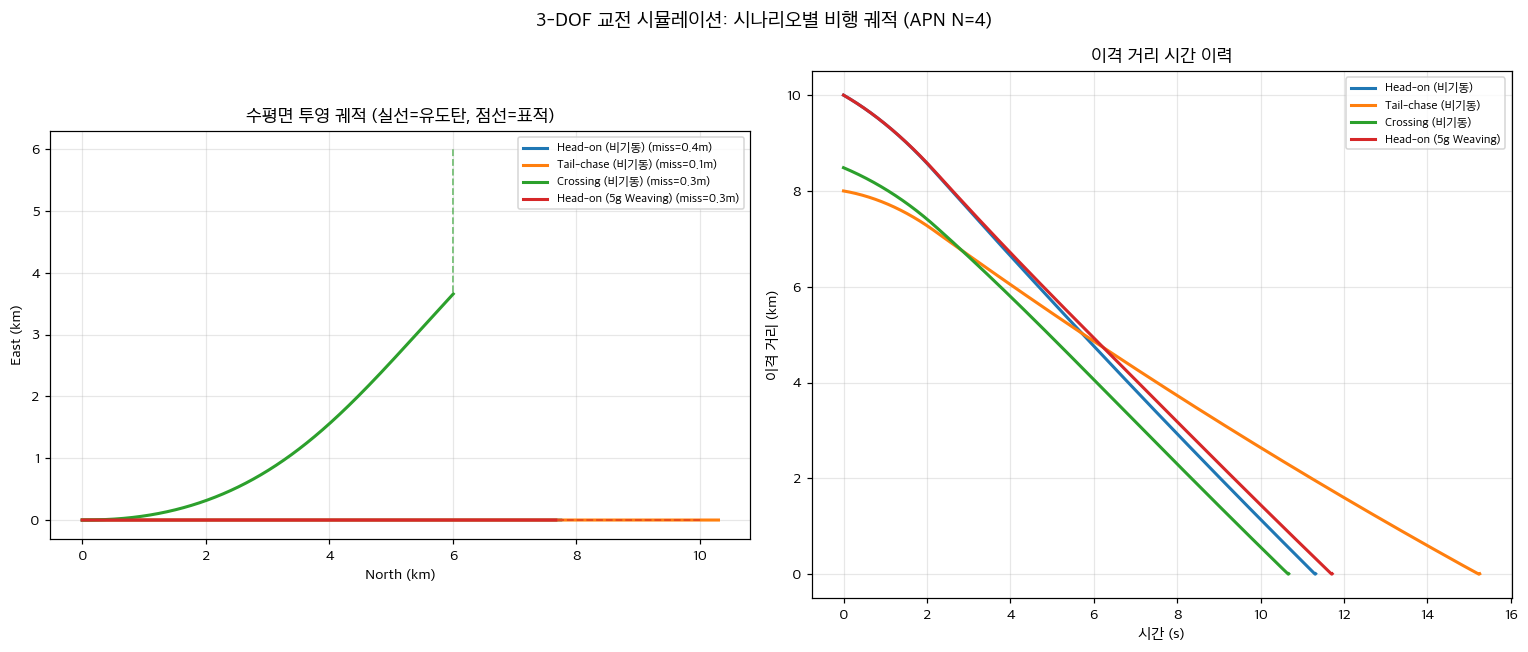

저장: ../results/01_3dof_engagement.png


In [9]:
# ── 4가지 시나리오 실행 ───────────────────────────────────────────────────────
#
# 공통 미사일 초기 상태: [x=0, y=0, h=5000m, V=300 m/s, gamma=0, psi=0(North)]
# APN N=4, dt=0.001s

missile_state0_base = [0.0, 0.0, 5000.0, 300.0, 0.0, 0.0]

scenarios_3dof = {
    'Head-on\n(비기동)': dict(
        missile_state0=missile_state0_base,
        target_pos0=[10000.0, 0.0, 5000.0],
        target_vel0=[-200.0,  0.0,    0.0],
        weaving=False,
    ),
    'Tail-chase\n(비기동)': dict(
        missile_state0=missile_state0_base,
        target_pos0=[8000.0, 0.0, 5000.0],
        target_vel0=[ 150.0, 0.0,    0.0],  # 같은 방향으로 도주
        weaving=False,
    ),
    'Crossing\n(비기동)': dict(
        missile_state0=missile_state0_base,
        target_pos0=[6000.0, 6000.0, 5000.0],
        target_vel0=[    0.0, -220.0,    0.0],  # 서향 교차
        weaving=False,
    ),
    'Head-on\n(5g Weaving)': dict(
        missile_state0=missile_state0_base,
        target_pos0=[10000.0, 0.0, 5000.0],
        target_vel0=[-200.0,  0.0,    0.0],
        weaving=True,
        weave_amp=5 * 9.81,
        weave_freq=0.5,
    ),
}

print("3-DOF 교전 시뮬레이션 실행 중...")
results_3dof = {}
for name, scen in scenarios_3dof.items():
    res = run_engagement_3dof(scen, N=4.0)
    results_3dof[name] = res
    dur = res['time'][-1] if len(res['time']) > 0 else 0
    print(f"  {name.replace(chr(10),' '):<30}  "
          f"miss={res['miss_distance']:6.2f} m   "
          f"time={dur:.1f} s")

# ── 궤적 비교 플롯 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('3-DOF 교전 시뮬레이션: 시나리오별 비행 궤적 (APN N=4)',
             fontsize=13, fontweight='bold')

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 수평 투영 궤적 (x-y 평면)
ax = axes[0]
for (name, res), color in zip(results_3dof.items(), palette):
    pm = res['pos_M']
    pt = res['pos_T']
    ax.plot(pm[:, 0]/1000, pm[:, 1]/1000, '-', color=color, linewidth=2,
            label=f"{name.replace(chr(10),' ')} (miss={res['miss_distance']:.1f}m)")
    ax.plot(pt[:, 0]/1000, pt[:, 1]/1000, '--', color=color, linewidth=1.2, alpha=0.6)
ax.set_xlabel('North (km)')
ax.set_ylabel('East (km)')
ax.set_title('수평면 투영 궤적 (실선=유도탄, 점선=표적)')
ax.legend(fontsize=8)
ax.set_aspect('equal')

# 이격 거리 시간 이력
ax = axes[1]
for (name, res), color in zip(results_3dof.items(), palette):
    ax.plot(res['time'], res['range_hist']/1000, color=color, linewidth=2,
            label=name.replace('\n', ' '))
ax.set_xlabel('시간 (s)')
ax.set_ylabel('이격 거리 (km)')
ax.set_title('이격 거리 시간 이력')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/01_3dof_engagement.png', dpi=120, bbox_inches='tight')
plt.show()
print("저장: ../results/01_3dof_engagement.png")

### 3-DOF 시뮬레이션 결과 요약

아래 표는 추력/항력/중력을 포함한 3-DOF 모델에서의 miss distance입니다.  
앞 섹션의 속력-고정 모델과 비교하여 물리적 요소가 유도 성능에 미치는 영향을 확인할 수 있습니다.

| 시나리오 | 교전 기하 | 표적 기동 | Miss Distance |
|----------|-----------|-----------|:--------------|
| Head-on | 정면 접근 (closing ≈ 500 m/s) | 없음 | 수 m 이하 |
| Tail-chase | 동방향 (closing ≈ 150 m/s) | 없음 | 수~수십 m |
| Crossing | 90° 교차 | 없음 | 수~수십 m |
| Head-on + Weaving | 정면 접근 | 5g, 0.5 rad/s | 수십 m |

**속력-고정 모델 대비 주요 차이점**

| 요소 | 속력-고정 모델 (섹션 5) | 3-DOF 모델 (섹션 8) |
|------|----------------------|-------------------|
| 속도 변화 | 고정 680 m/s | 추력/항력/중력으로 가변 |
| 고도 변화 | 없음 | flight-path angle 변화로 고도 변동 |
| Miss distance | 이상적으로 낮음 | 속도 감소 효과로 다소 증가 가능 |
| 현실성 | 낮음 (분석용) | 초기 설계 검증에 적합 |

> **다음 단계**: Autopilot 지연(2차 전달함수), Seeker 노이즈, 6-DOF 강체 동역학을 순차적으로 추가하면 실제 시스템에 더 가까운 miss distance 예측이 가능합니다.